# Expressing Kimi K3

This notebook writes Kimi K3, the open-weight model of Moonshot AI, as one algebraic expression and draws it part by part against the inference code Moonshot AI ships with the checkpoint. The expression computes the text model with its two kinds of attention, the delta attention of 69 layers and the gated latent attention of 24, and the attention residuals that join the layers. The last cell writes the model into one interactive page. `notebooks/website/modern/validate_kimi_k3.py` checks every fact the notebook states about the expression, and two of its checks evaluate parts of the expression on numbers against the reference.

*Written by Claude Opus 5.5 (1M context) at effort 40 on 2026-09-28.*

In [1]:
import notebooks.display.notebook_diagrams as notebook_diagrams
import notebooks.display.sota_figures as figures
import notebooks.sota.KimiK3.assemble_page_variants as assemble_page_variants
import notebooks.sota.KimiK3.operator_explanations as operator_explanations
import notebooks.sota.KimiK3.released_constants as released_constants
import notebooks.sota.KimiK3.slide_causal_reads as slide_causal_reads
import notebooks.sota.KimiK3.whole_model as whole_model
import notebooks.website.website_output as website_output
import dataclasses
from IPython.display import Markdown, display
from notebooks.sota.KimiK3.block_titles_and_descriptions import TEXT as text

DIAGRAMS = operator_explanations.with_explanation_tables(
    figures.DiagramSettings(
        mode=figures.DiagramMode.INLINE,
        dark_mode=notebook_diagrams.ColorMode.LIGHT,
        tape=figures.TapePresentation.ABSORBED,
        axis_sizes=figures.AxisSizes.SUBSCRIPT,
        axis_label_font_size=0.8,
        block_recycling=figures.BlockRecycling.RECYCLED,
        advanced_display=figures.AdvancedDisplay.LEGEND,
        expanded_parameters=figures.ExpandedParameters.WEIGHT_ARRAYS,
        title='Kimi K3'))
PAGE = dataclasses.replace(
    assemble_page_variants.page_settings(figures.DiagramMode.HTML),
    page_directory=website_output.MODERN_PAGES)

figures.forget_drawn_blocks()

MODEL = whole_model.kimi_k3
DECODE = slide_causal_reads.kimi_k3_slid
assigned_sizes = whole_model.released_assigned_sizes()

## Reading the figures

A figure is a neural circuit diagram of one expression. Every wire is an array, and the label on a wire names the axes of that array with the size of each axis written as a subscript. An operator is a shape drawn across its operands and its results. A wire passes through an operator when the operator is broadcast over the axis of that wire, and a broadcast operator computes the same function separately at every index of the axis. A wire ends at an operator when the operator consumes the axis, and the function of the operator then reads every index of the axis together. A linear map of the hidden state is the same map at every token, so it is broadcast over the token axis. The scan of the delta attention carries a state from each token to the next, so it consumes the token axis.

A block is a titled box around a part of the expression, and a block whose repetition is greater than one denotes a loop. A box is drawn beside its body the first time that body appears and as the box alone afterwards, so a mechanism is explained once and referred to later, and the figures below are ordered so that each one introduces the bodies used by the next. On the interactive page, resting the pointer over a box or an operator opens an inspection box with its formula, a description and a link to the lines of the reference expressed by it.

A value an iteration of a loop hands to the next iteration travels on the tape rather than on a wire. The iteration begins with a grab from a named slot and ends with a drop onto the same slot. The scan of the delta attention has two such values, the state of every head on the slot S and the output written so far on the slot O.

No size appears in the expression. Each axis carries a free symbol, and the sizes of the configuration are written onto the labels when a figure is drawn, so a formula reads with its symbols and one table binds the numbers.

| axis | size | what it indexes |
| --- | --- | --- |
| `x`, `v` | symbolic, 163840 | the token positions of the prompt, and the vocabulary |
| `m` | 7168 | the width of the hidden state |
| `j`, `d`, `z` | 96, 128, 128 | the heads of the delta attention, the key channels of a head, and its value channels |
| `w`, `s` | 4, $\lvert d \rvert$ | the taps of the causal convolution, and the rank the decays are projected through |
| `h`, `q`, `c` | 96, 1536, 512 | the heads of the latent attention, the query low rank, and the key-value latent |
| `n`, `p`, `a`, `u` | 128, 64, $\lvert n \rvert + \lvert p \rvert$, 128 | the key channels expanded from the latent, the key channels every head shares, the whole query and key head, and the value channels |
| `r` | $\lvert x \rvert$ | the distance counted back from a query |
| `b` | 9 | the entries of the attention residuals |
| `e`, `k`, `l`, `f` | 896, 16, 3584, 3072 | the routed experts, the experts kept for one token, the latent the experts read and write, and the width of an expert |
| `t`, `g` | 6144, 33792 | the width of the shared experts, and the width of the dense MLP of layer 0 |

Three axes hold a value at some of their positions and nothing at the others. The distance axis `r|x` counts back from a query, so distance $i_{r}$ of query $i_{x}$ holds a value when $i_{x} - i_{r} \geq 0$. The tap axis `w|x` counts back from a token in the same way. The entry axis `b` holds a value at the entries of the blocks already reached. A position holding nothing holds the universal unit. Every sum, maximum and contraction ignores the unit, and every elementwise map preserves it, so causality is stated once, at the view that reads back from a token, and reaches every consumer with no mask written anywhere.

Beside each figure stands a legend with one row per named axis of the term. The axis stands on the left, the integer of its size in the middle, and on the right the code form carried by its name, which is the name of the axis in generated code.

Every constant of the reference is a named symbol in the expression as well, so no size assigned to an axis can reach a constant. The table below gives the value of each symbol in the reference and the line that sets it.

In [2]:
display(Markdown(released_constants.released_constants_table()))

| symbol | value in the reference | meaning | line |
|---|---|---|---|
| $\varepsilon$ | $10^{-5}$ | the number added under the square root of every RMS normalisation built with `rms_norm_eps` | [config.json L245](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/config.json#L245) |
| $\varepsilon_{\mathrm{l}}$ | $10^{-6}$ | the number added under the square root of the RMS normalisations of the query low rank and of the key-value latent | [modeling_kimi_linear.py L227](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L227) |
| $\varepsilon_{\mathrm{q}}$ | $10^{-6}$ | the number added under the square root of the L2 normalisation of the queries and the keys of the delta attention | [fla l2norm.py L148-L160](https://github.com/fla-org/flash-linear-attention/blob/9c8e42e762fce087c27b673af4922795d9edb85e/fla/modules/l2norm.py#L148-L160) |
| $\lambda$ | $-5$ | `gate_lower_bound`, the smallest logarithm of the decay of a key channel in one token | [config.json L93](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/config.json#L93) |
| $\beta$ | $4$ | `activation_situ_beta`, the bound of the hyperbolic tangent on the gate branch of SiTU | [config.json L20](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/config.json#L20) |
| $\beta_{\mathrm{u}}$ | $25$ | `activation_situ_linear_beta`, the bound of the hyperbolic tangent on the up branch of SiTU | [config.json L21](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/config.json#L21) |
| $\varepsilon_{\mathrm{r}}$ | $10^{-20}$ | the number added to the sum of the sixteen kept gates before each gate is divided by that sum | [modeling_kimi_linear.py L754](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L754) |

## Kimi K3 and its reference implementation

Kimi K3 is a decoder-only transformer of 93 layers with a hidden width of 7,168 and a vocabulary of 163,840 tokens ([config.json L187](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/config.json#L187), [config.json L50](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/config.json#L50), [config.json L267](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/config.json#L267)). Moonshot AI published the weights on 2026-07-27 in the model repository `moonshotai/Kimi-K3` on Hugging Face, whose initial commit carries that date. The safetensors files hold 2.78 trillion parameters, counted by the Hugging Face API on 2026-09-28, and the context runs to 1,048,576 tokens ([config.json L171](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/config.json#L171)).

Three mechanisms separate the architecture from the transformer of DeepSeek-V3, from whose code the reference adapts its latent attention and its mixture of experts ([L1-L10](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L1-L10)). 69 of the 93 layers attend with Kimi Delta Attention, a linear attention that carries a state of fixed size from each token to the next and keeps no cache of keys and values. The other 24 layers attend with multi-head latent attention, which holds no rotary embedding here and gates the output of every head. The residual stream is replaced by attention residuals, in which each sublayer reads a softmax-weighted mean of the embedding and of the sums of the outputs of earlier blocks of twelve layers.

The reference is the remote code the configuration names in its `auto_map`. `KimiK3ForConditionalGeneration` in `modeling_kimi_k3.py` joins the vision encoder MoonViT-V2 to the text model `KimiLinearForCausalLM` ([modeling_kimi_k3.py L893-L926](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_k3.py#L893-L926)), which is written in `modeling_kimi_linear.py` and configured by `KimiLinearConfig` in `configuration_kimi_k3.py`. The delta attention calls three kernels and two modules of the `fla-core` package, and the notebook reads `fla` at the tag `v0.5.2`, released on the day the weights were released. `fla` states the recurrence its kernel computes as a loop in PyTorch, `naive_recurrent_kda` ([fla naive.py L12-L66](https://github.com/fla-org/flash-linear-attention/blob/9c8e42e762fce087c27b673af4922795d9edb85e/fla/ops/kda/naive.py#L12-L66)), and the expression follows that loop. The vision encoder is left out, and a prompt of text reaches the layers as its embeddings unchanged.

## The causal convolution of the delta attention

A delta layer projects the hidden state onto the queries, the keys and the values of 96 heads of 128 channels each, and passes each projection through a short causal convolution before the attention reads it ([L498-L518](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L498-L518), [L580-L600](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L580-L600)). The convolution is the `ShortConvolution` of `fla`, a depthwise `nn.Conv1d` of four taps with no bias, padded by three zeros in front of the sequence and followed by the SiLU ([fla short_conv.py L24-L69](https://github.com/fla-org/flash-linear-attention/blob/9c8e42e762fce087c27b673af4922795d9edb85e/fla/modules/conv/short_conv.py#L24-L69)). Output channel $i_{d}$ of token $i_{x}$ is

$$y[i_{x}, i_{j}, i_{d}] = \mathrm{SiLU}\Big(\sum_{i_{w} \in w} W^{C}[i_{w}, i_{j}, i_{d}]\, v[i_{x} - i_{w}, i_{j}, i_{d}]\Big).$$

The view named Taps reads the projection at token $i_{x} - i_{w}$ for every tap $i_{w}$ of every token $i_{x}$. A tap that counts back past the first token reads the universal unit, which the sum over the taps ignores, as the three zeros of the padding add nothing in the reference. The taps are read by a linear map from the tap axis onto every channel, and the view named Depthwise keeps the entries where the channel of the filter is the channel of the value, which is what makes the convolution depthwise. `nn.Conv1d` stores the weights of a channel from the oldest token to the newest, and the tap axis counts back from the newest token, so tap $i_{w}$ holds the weight stored at position $3 - i_{w}$.

The causal convolution of the queries, drawn as its box beside its body: the view that reads four taps back from every token, the linear map of the taps onto every channel, the depthwise diagonal, and the SiLU.


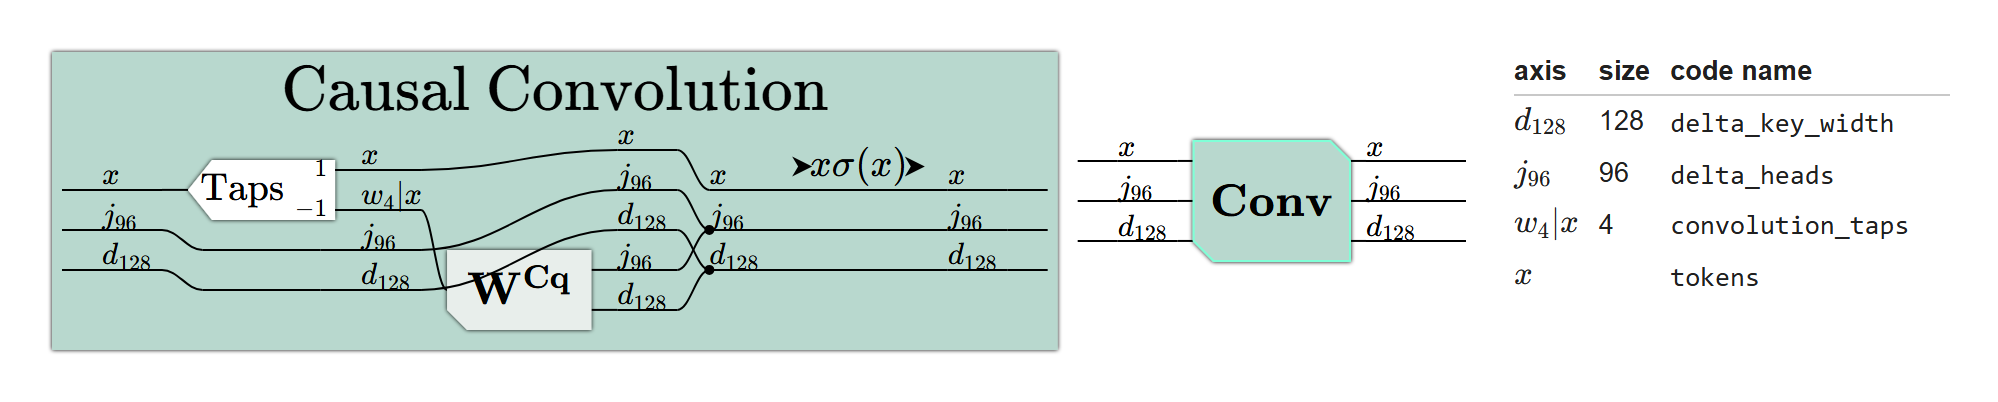

In [3]:
await figures.show(
    whole_model.part_named('Conv', MODEL),
    'The causal convolution of the queries, drawn as its box beside its body: the view '
    'that reads four taps back from every token, the linear map of the taps onto every '
    'channel, the depthwise diagonal, and the SiLU.',
    width=1300, sub_blocks=figures.SubBlocks.EVERY_BODY,
    assigned_sizes=assigned_sizes, settings=DIAGRAMS)

## The queries, the keys, the decays and the strengths

The reference hands the queries, the keys, the values, a raw decay and a raw strength to `chunk_kda`, and asks the kernel to finish them before the recurrence with three flags: `use_qk_l2norm_in_kernel`, `use_gate_in_kernel` and `use_beta_sigmoid_in_kernel` ([L609-L627](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L609-L627)). The expression computes all three before the scan, as operations broadcast over the tokens.

The queries and the keys are divided by their length over the 128 key channels, after $\varepsilon_{\mathrm{q}}$ is added to the sum of the squares ([fla chunk.py L54-L58](https://github.com/fla-org/flash-linear-attention/blob/9c8e42e762fce087c27b673af4922795d9edb85e/fla/ops/kda/chunk.py#L54-L58), [fla l2norm.py L27-L46](https://github.com/fla-org/flash-linear-attention/blob/9c8e42e762fce087c27b673af4922795d9edb85e/fla/modules/l2norm.py#L27-L46)). The queries are then multiplied by $\lvert d \rvert^{-1/2}$, the scale `chunk_kda` takes when it is given none ([fla chunk.py L414-L415](https://github.com/fla-org/flash-linear-attention/blob/9c8e42e762fce087c27b673af4922795d9edb85e/fla/ops/kda/chunk.py#L414-L415)).

The decay of key channel $i_{d}$ of head $i_{j}$ is read off the hidden state through a projection onto a rank of 128 and back onto the 12,288 channels of the heads, `f_a_proj` and `f_b_proj` ([L523-L524](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L523-L524), [L601-L602](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L601-L602)). The configuration sets `gate_lower_bound` to -5 ([config.json L93](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/config.json#L93)), and the gate of `fla` with a lower bound gives the decay

$$\alpha[i_{x}, i_{j}, i_{d}] = \exp\Big(\lambda\, \sigma\big(e^{A[i_{j}]}\, (f[i_{x}, i_{j}, i_{d}] + b^{\Delta}[i_{j}, i_{d}])\big)\Big),$$

with $A$ the parameter `A_log` of one number per head and $b^{\Delta}$ the parameter `dt_bias` of one number per channel ([fla gate.py L58-L70](https://github.com/fla-org/flash-linear-attention/blob/9c8e42e762fce087c27b673af4922795d9edb85e/fla/ops/kda/gate.py#L58-L70), [fla chunk_fwd.py L43-L56](https://github.com/fla-org/flash-linear-attention/blob/9c8e42e762fce087c27b673af4922795d9edb85e/fla/ops/kda/chunk_fwd.py#L43-L56)). The logarithm of the decay lies between $\lambda = -5$ and 0, so a key channel keeps between 0.0067 of its state and all of it from one token to the next. The decay has one number per key channel, where the gated delta rule of Gated DeltaNet has one number per head, and the per-channel decay is the change Kimi Delta Attention makes. The strength of the write of every head is a projection of the hidden state onto one number per head passed through a sigmoid ([L529](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L529), [L603](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L603), [fla chunk.py L60-L62](https://github.com/fla-org/flash-linear-attention/blob/9c8e42e762fce087c27b673af4922795d9edb85e/fla/ops/kda/chunk.py#L60-L62)).

The decays: the projection through a rank of 128, the bias of every channel, the factor e^A of every head, and the gate exp(-5 sigma(x)).


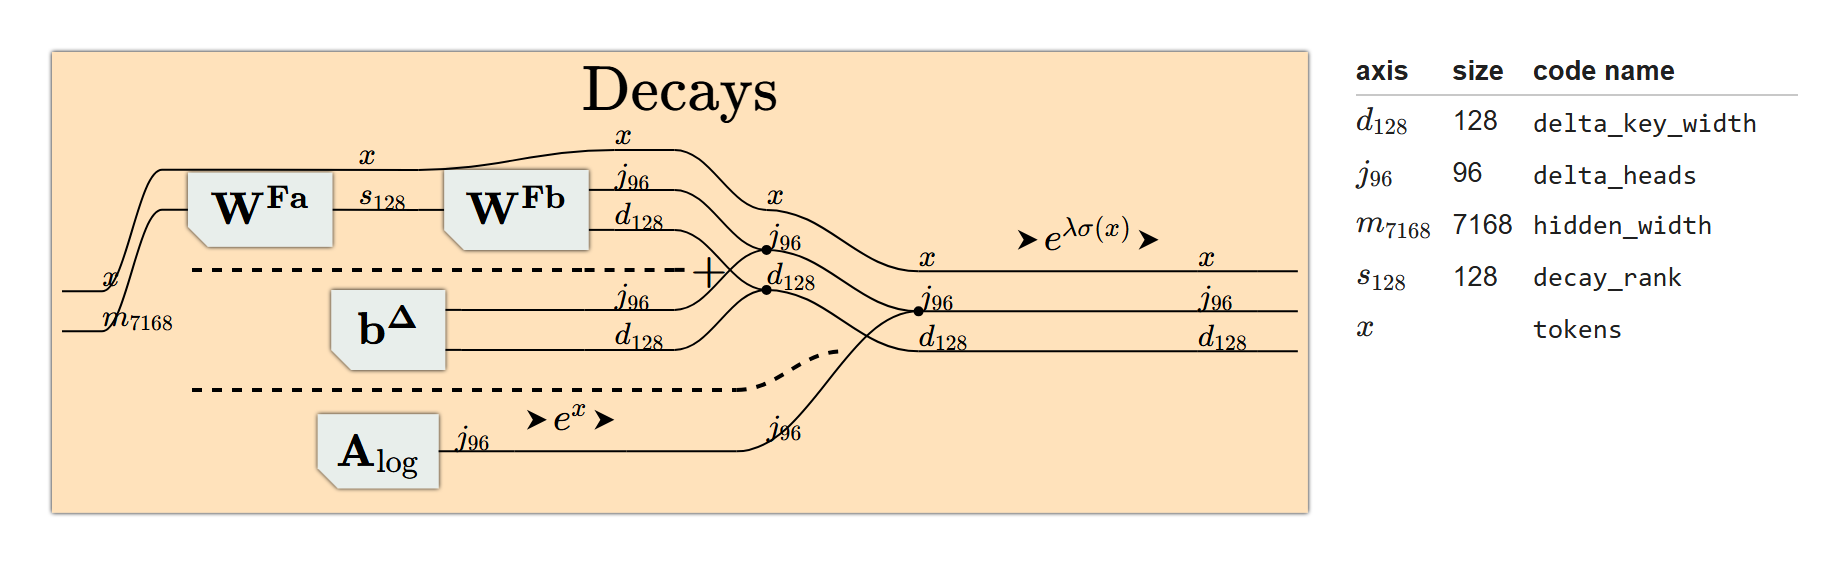

The L2 normalisation of one head of one token, drawn as its box beside its body.


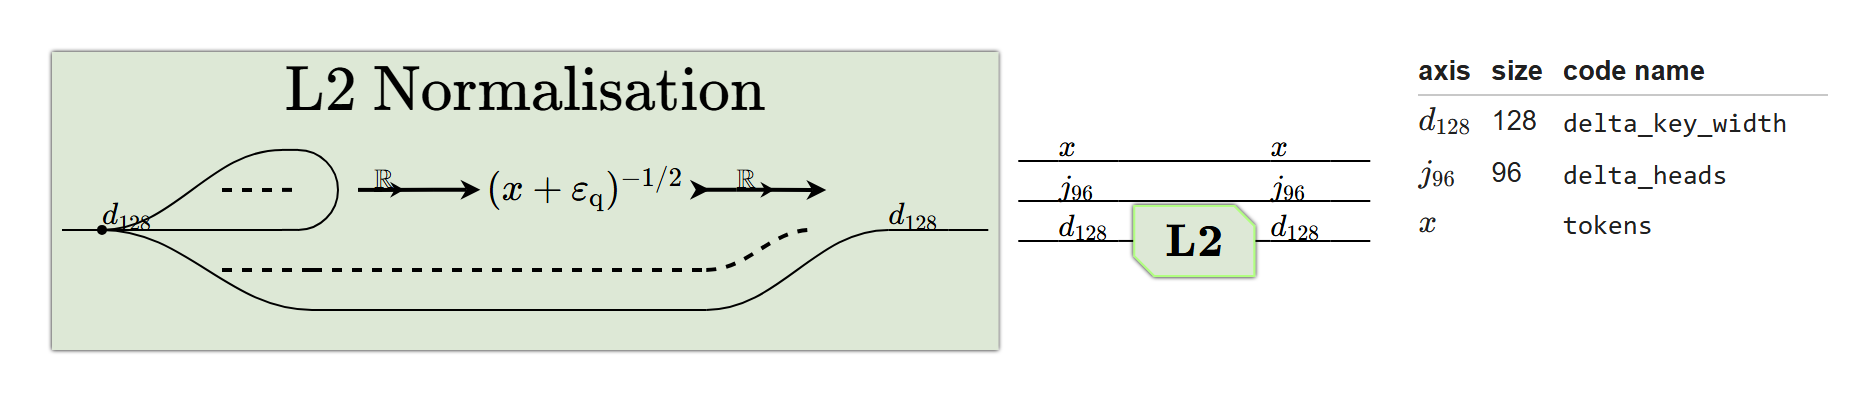

In [4]:
await figures.show(
    whole_model.part_titled(text.DECAY_TITLE, DECODE),
    'The decays: the projection through a rank of 128, the bias of every channel, the '
    'factor e^A of every head, and the gate exp(-5 sigma(x)).',
    width=1300, assigned_sizes=assigned_sizes, settings=DIAGRAMS)

await figures.show(
    whole_model.part_named('L2', DECODE),
    'The L2 normalisation of one head of one token, drawn as its box beside its body.',
    width=1000, sub_blocks=figures.SubBlocks.EVERY_BODY,
    assigned_sizes=assigned_sizes, settings=DIAGRAMS)

## The delta rule scan

Every head holds a state $S$, a matrix of 128 key channels by 128 value channels, which starts at zero and is carried from each token to the next. At token $t$ every row of the state is multiplied by the decay of its key channel. The key reads the value the decayed state predicts for it, the difference between the value and the prediction is multiplied by the strength and by the key, and the product is added to the state. The query reads the new state:

$$S_{t} = \alpha_{t} S_{t-1} + \beta_{t}\, k_{t} \big(v_{t} - k_{t}^{\top} \alpha_{t} S_{t-1}\big)^{\top}, \qquad o_{t} = S_{t}^{\top} q_{t}.$$

The write moves the state towards storing the value at the key, which is the delta rule of DeltaNet, and the length of the key is one after its normalisation. `naive_recurrent_kda` writes these steps in this order ([fla naive.py L59-L63](https://github.com/fla-org/flash-linear-attention/blob/9c8e42e762fce087c27b673af4922795d9edb85e/fla/ops/kda/naive.py#L59-L63)). `chunk_kda` computes the same recurrence in blocks of 64 tokens, and `fused_recurrent_kda` computes it one token at a time when the reference decodes one token with a cache ([L561](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L561), [L609-L645](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L609-L645)).

The scan is a block repeated once per token, whose counter $i_{x}$ its tag names. The state of every head is a loop variable on the slot S, and the output over every token is a second loop variable on the slot O, which each iteration adds its token's output to at position $i_{x}$. The queries, the keys, the values, the decays and the strengths enter the loop on wires over every token, and each iteration reads its own token through a view at the counter. A server keeps the 96 states of 128 by 128 numbers of every delta layer from one pass to the next, which is 1,572,864 numbers per layer, whatever the length of the context.

The delta rule scan, drawn as its box beside its body: the loop over the tokens, the grabs of the state and of the output so far, the decay of the state, the prediction at the key, the correction along the key, the read of the new state by the query, and the write of the output at the token.


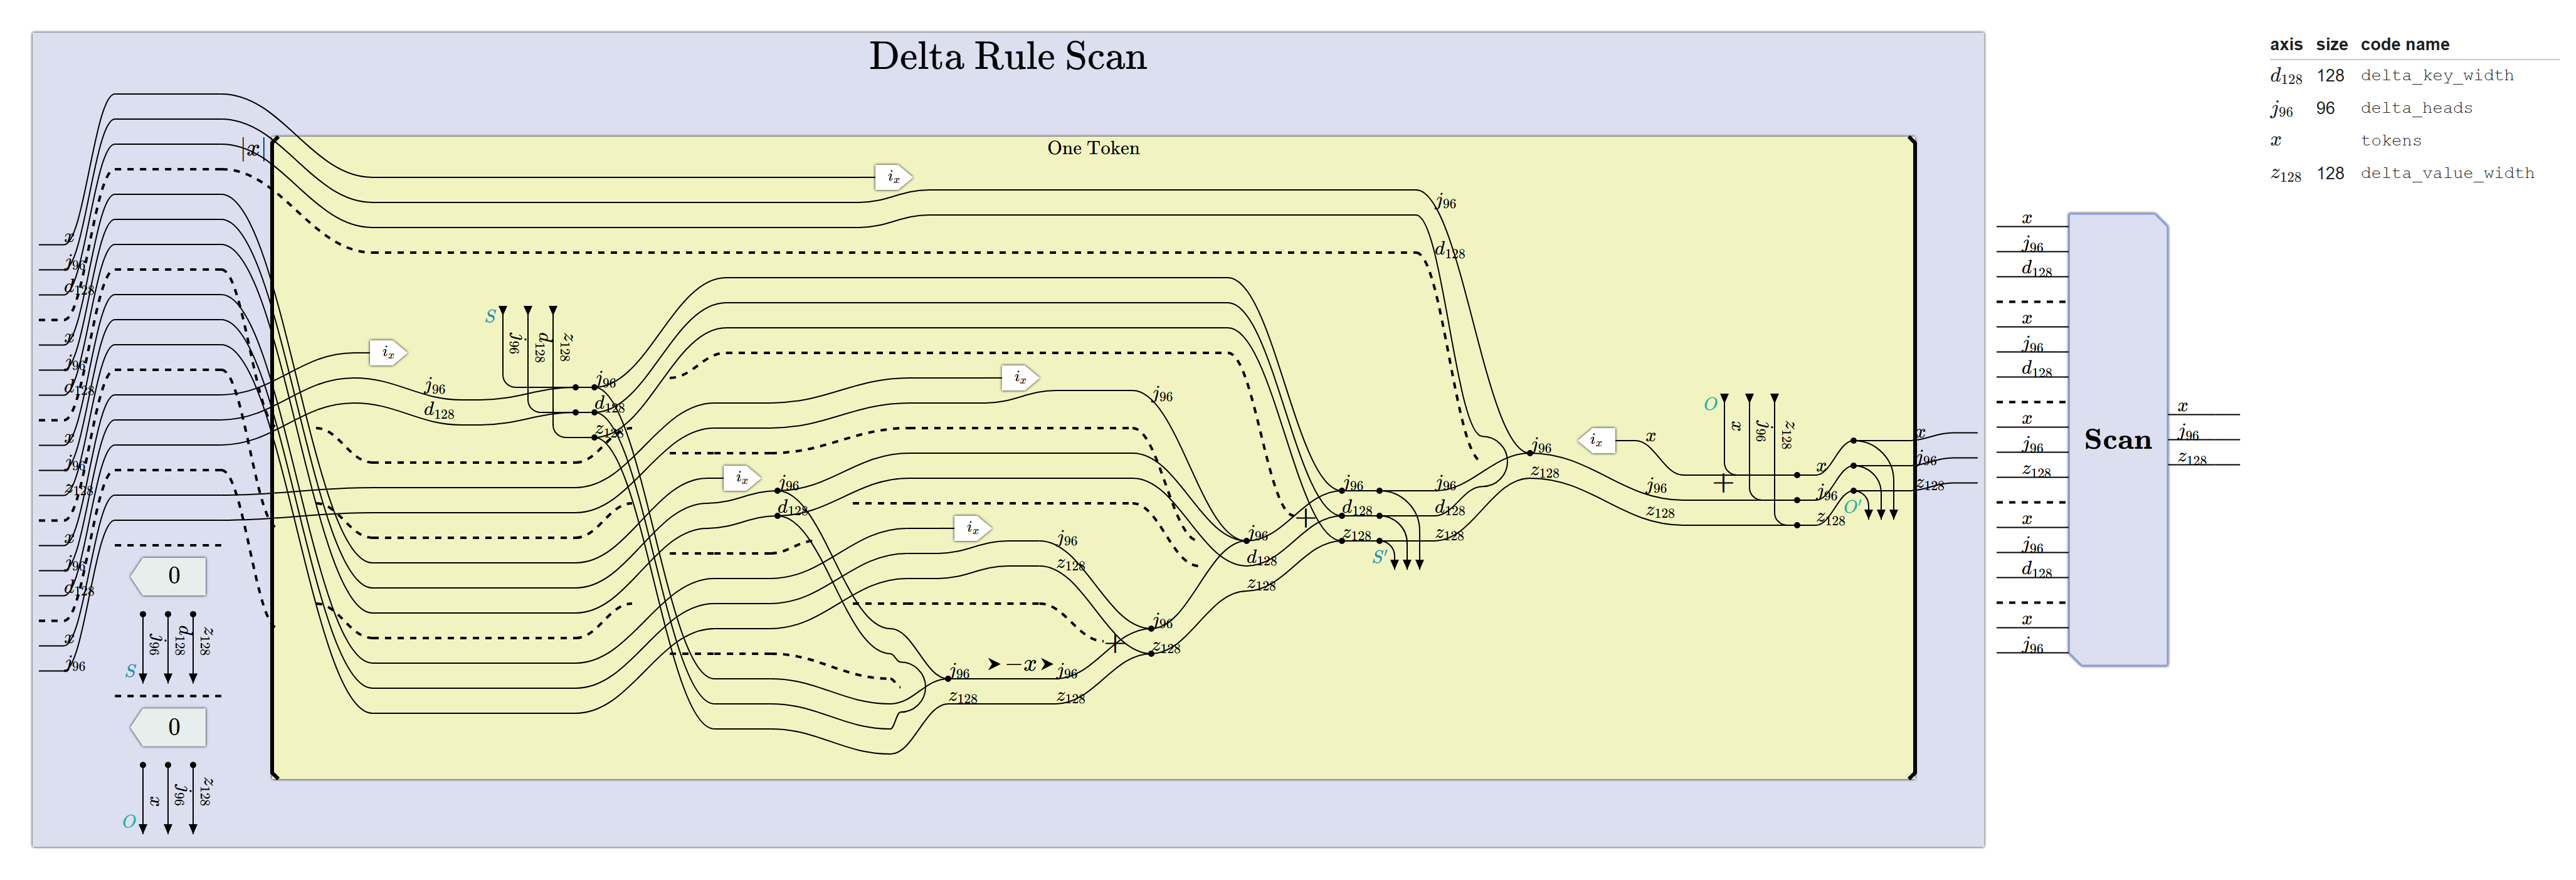

In [5]:
await figures.show(
    whole_model.part_named('Scan', DECODE),
    'The delta rule scan, drawn as its box beside its body: the loop over the tokens, '
    'the grabs of the state and of the output so far, the decay of the state, the '
    'prediction at the key, the correction along the key, the read of the new state by '
    'the query, and the write of the output at the token.',
    width=2400, sub_blocks=figures.SubBlocks.EVERY_BODY,
    assigned_sizes=assigned_sizes, settings=DIAGRAMS)

## The gated output and the delta layer

The output of the scan is normalised by an RMS normalisation over the 128 value channels of each head, with a gain shared by the 96 heads, and multiplied by the sigmoid of a projection of the hidden state onto every channel of every head ([L539-L541](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L539-L541), [L651-L659](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L651-L659)). The reference computes the two steps in one kernel, `FusedRMSNormGated` with the sigmoid activation ([fla fused_norm_gate.py L98-L104](https://github.com/fla-org/flash-linear-attention/blob/9c8e42e762fce087c27b673af4922795d9edb85e/fla/modules/fused_norm_gate.py#L98-L104)). An output projection maps the result back onto the hidden width.

The figure draws the delta attention in the CausalSlide, which the section on reading back from each token explains. The one view named Taps stands at the copy of the hidden state, and the three projections run over the tokens and the taps before their convolutions.

Kimi Delta Attention: the queries, the keys and the values convolved over the last four tokens, the decays and the strengths, the scan, and the gated output.


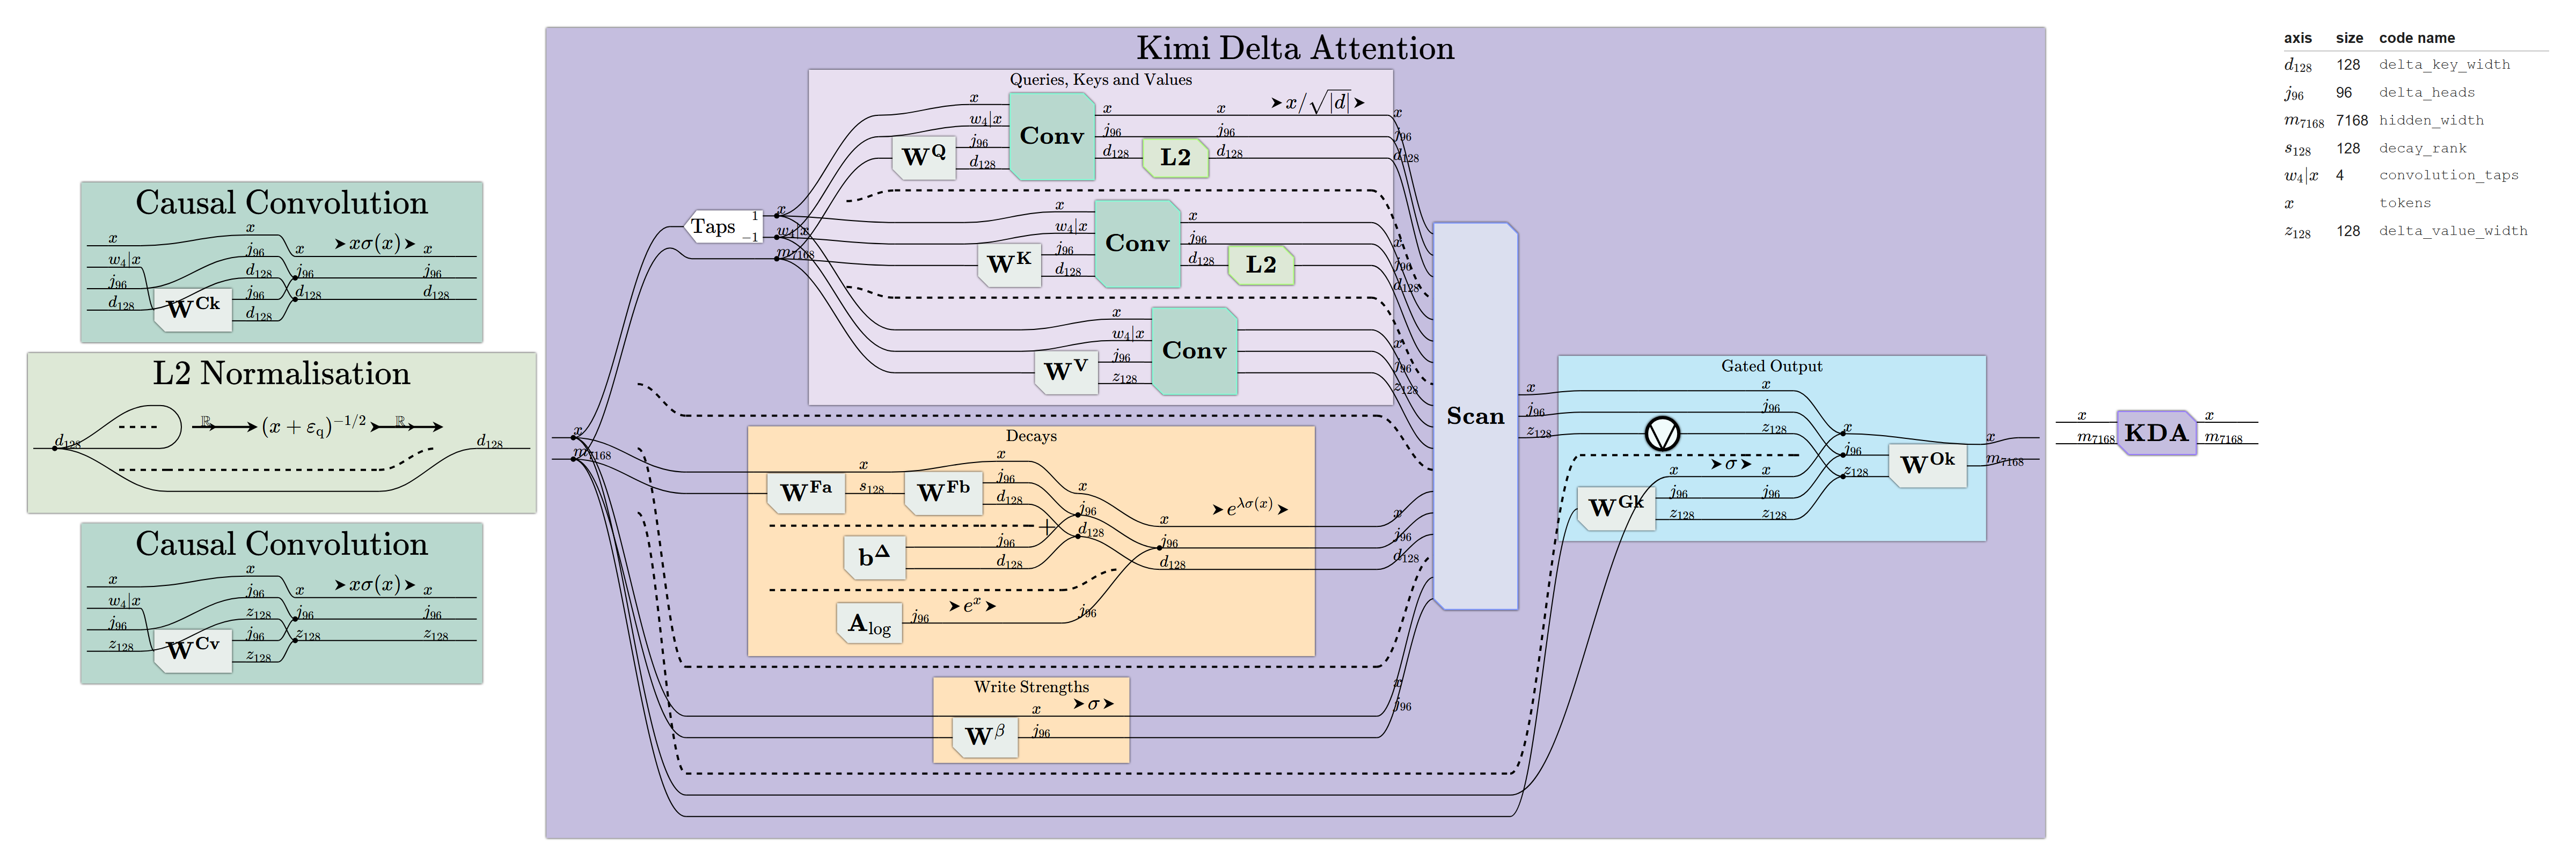

In [6]:
await figures.show(
    whole_model.part_named('KDA', DECODE),
    'Kimi Delta Attention: the queries, the keys and the values convolved over the last '
    'four tokens, the decays and the strengths, the scan, and the gated output.',
    width=1800, assigned_sizes=assigned_sizes, settings=DIAGRAMS)

## The gated latent attention

Layers 3, 7, 11 and every fourth layer after them, and layer 92, attend with `KimiMLAAttention` ([L335-L474](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L335-L474)). The query passes through a low rank of 1,536 channels and an RMS normalisation, and one projection gives each of the 96 heads a query of 192 channels ([L418-L424](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L418-L424)). The configuration sets `mla_use_nope` ([config.json L173](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/config.json#L173)), so the reference holds no rotary table and turns no channel ([L403](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L403)). The 192 channels of a query are cut into 128 and 64 and joined again in the same order, which leaves the query unchanged, so the expression writes it as one projection ([L422-L424](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L422-L424), [L439](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L439)).

The key of a head has two parts. A latent of 512 channels per token is projected from the hidden state and normalised, and the latent is expanded into 128 key channels and 128 value channels of every head ([L426-L433](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L426-L433)). 64 more key channels are projected from the hidden state once per token and copied to every head, which is the `k_rot` of the reference, named for a rotation this configuration does not apply ([L435-L440](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L435-L440)). The reference computes `kv_a_proj_with_mqa` and `kv_b_proj` as one weight each and cuts each result with `torch.split`, and the expression holds one weight per part: $W^{KVa}$ and $W^{Kr}$, and $W^{Kb}$ and $W^{Vb}$.

Every head of a query attends to every token at or before it. The keys and the values of every head are read back from each query through the view named Back, and the core computes the scores, the scale $\lvert a \rvert^{-1/2} = 192^{-1/2}$, the softmax over the distances and the sum of the values, once per query and head ([L311-L332](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L311-L332), [L359](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L359)). The model forces the attention of `flash_attention_2` ([L1110-L1117](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L1110-L1117)), and the kernel is passed `is_causal` by the layer ([L395](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L395)). The configuration sets `mla_use_output_gate` ([config.json L174](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/config.json#L174)), so the output of every head is multiplied by the sigmoid of a projection of the hidden state before the output projection ([L398-L401](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L398-L401), [L470-L473](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L470-L473)).

The gated latent attention in the CausalSlide: the hidden state read back from every query at its copy, the keys and the values at every query and distance, the queries, the core computed once per query and head, the output gate and the output projection.


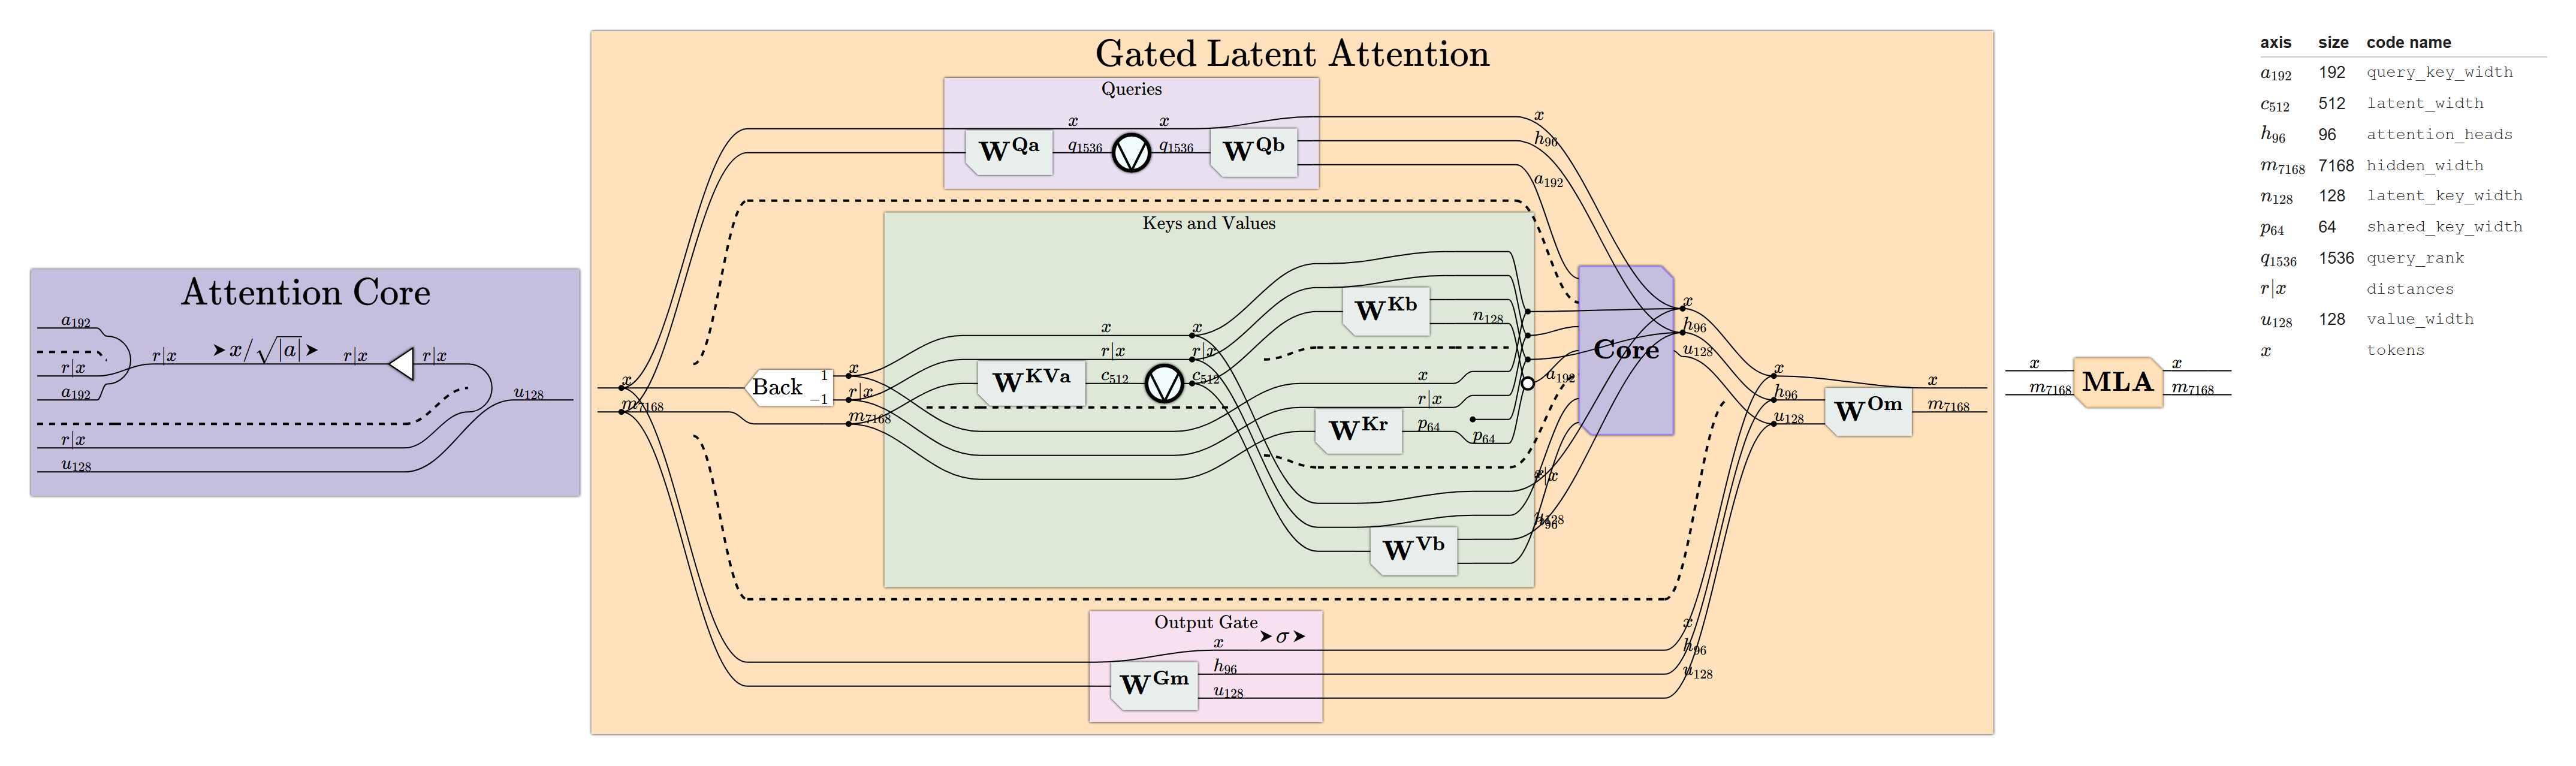

In [7]:
await figures.show(
    whole_model.part_named('MLA', DECODE),
    'The gated latent attention in the CausalSlide: the hidden state read back from every '
    'query at its copy, the keys and the values at every query and distance, the queries, '
    'the core computed once per query and head, the output gate and the output projection.',
    width=1600, sub_blocks=figures.SubBlocks.EVERY_BODY,
    assigned_sizes=assigned_sizes, settings=DIAGRAMS)

## The dense MLP and the latent mixture of experts

The feed-forward map of layer 0 is a dense SiTU-GLU of width 33,792, because the configuration sets `first_k_dense_replace` to 1 ([config.json L46](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/config.json#L46), [L893-L900](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L893-L900)), and the feed-forward map of every later layer is a mixture of experts. A SiTU-GLU projects the hidden state twice and joins the two branches with `SituAndMul` ([L64-L91](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L64-L91)). The gate branch is bounded by $\beta \tanh(x / \beta)$ and multiplied by its own sigmoid, the up branch is bounded by $\beta_{\mathrm{u}} \tanh(x / \beta_{\mathrm{u}})$, and the configuration sets $\beta = 4$ and $\beta_{\mathrm{u}} = 25$ ([config.json L20-L21](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/config.json#L20-L21)). A bounded tangent is close to the identity for a value much smaller than its bound and never leaves the interval between minus the bound and the bound. The package has no hyperbolic tangent, and the expression writes it as $\tanh(y) = 2 \sigma(2 y) - 1$.

The router of `KimiMoEGate` scores all 896 experts with a sigmoid of a linear map of the hidden state in FP32 ([L703-L712](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L703-L712)). A learned correction bias is added to one copy of the scores, and the 16 experts with the largest biased scores run ([L723](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L723), [L747-L749](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L747-L749)). The other copy holds no bias and is read at the 16 kept experts, so the bias decides which experts run and never scales their outputs ([L750](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L750)). The 16 gates are divided by their sum plus $\varepsilon_{\mathrm{r}}$ ([L753-L755](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L753-L755)). The configuration sets one group of experts and a `routed_scaling_factor` of 1 ([config.json L184](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/config.json#L184), [config.json L247](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/config.json#L247)), so the group step and the final scaling change no gate and the expression leaves them out.

The routed experts read a latent. `routed_expert_down_proj` maps the hidden state of 7,168 channels onto a latent of 3,584, every kept expert is a SiTU-GLU of width 3,072 from the latent to the latent, the gated sum of the experts is normalised by an RMS normalisation over the latent, and `routed_expert_up_proj` maps it back onto the hidden width ([L776-L813](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L776-L813), [L821-L832](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L821-L832)). An expert-parallel server sends the latent to the processor that holds an expert, which moves half the bytes the hidden state would. Each weight of the experts produces the expert axis, so its implicit weight holds all 896 experts, and a diagonalisation after the down projection keeps the output of the expert chosen at each slot. The gates land on the outputs of the experts as one contraction over the 16 slots, which the reference computes in FP32 after the experts ([L867-L873](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L867-L873)). The two shared experts are one SiTU-GLU of width 6,144, twice the width of a routed expert, which reads the hidden state ([L797-L801](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L797-L801)), and its output is added to the output of the routed experts ([L836-L837](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L836-L837)).

The dense MLP of layer 0, one SiTU-GLU of width 33792 computed once per token.


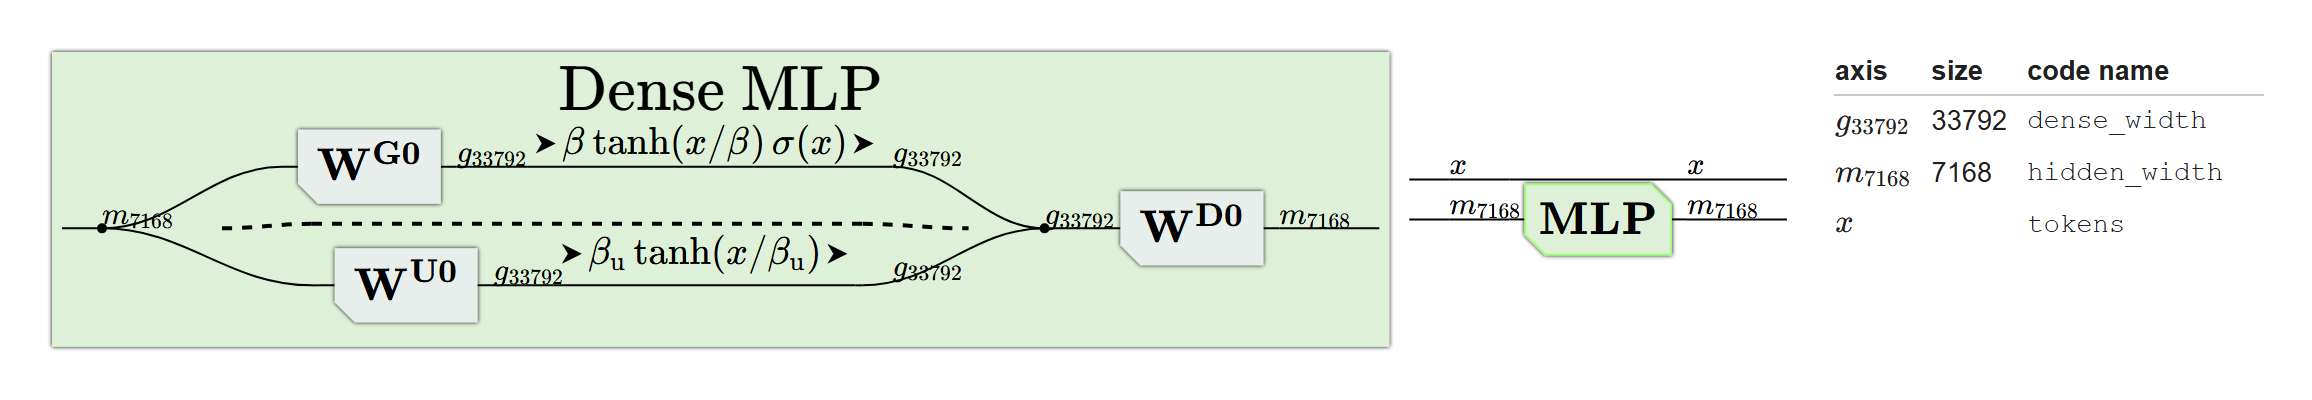

The mixture of experts of one token: the router box, the projection onto the latent, the 16 kept experts with their diagonal, the contraction with the gates, the normalisation of the latent, the projection back, and the shared experts.


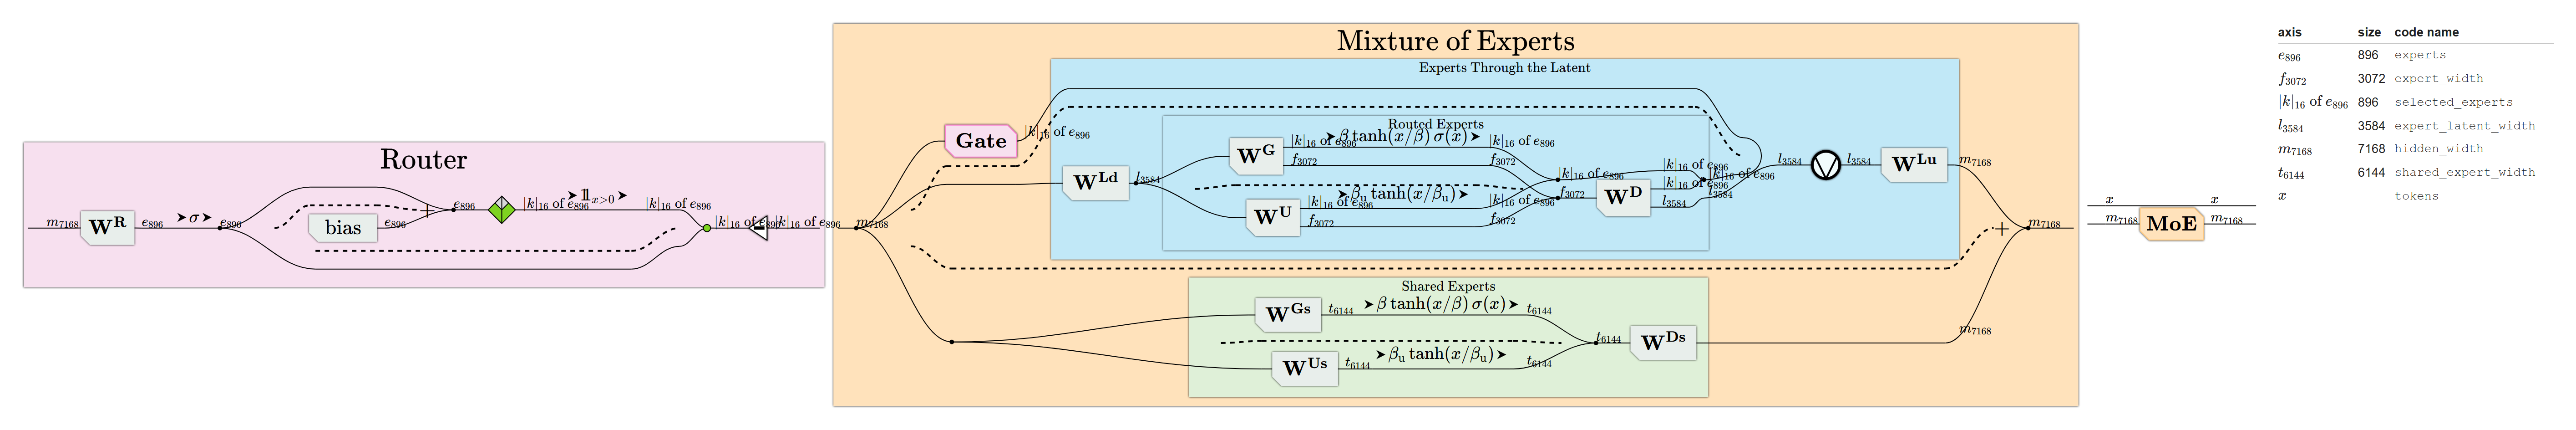

In [8]:
await figures.show(
    whole_model.part_named('MLP', DECODE),
    'The dense MLP of layer 0, one SiTU-GLU of width 33792 computed once per token.',
    width=1200, assigned_sizes=assigned_sizes, settings=DIAGRAMS)

await figures.show(
    whole_model.part_named('MoE', DECODE),
    'The mixture of experts of one token: the router box, the projection onto the '
    'latent, the 16 kept experts with their diagonal, the contraction with the gates, the '
    'normalisation of the latent, the projection back, and the shared experts.',
    width=1800, assigned_sizes=assigned_sizes, settings=DIAGRAMS)

## The attention residuals

A transformer layer usually reads the hidden state, which is the embedding plus the output of every sublayer so far. `_forward_attn_residual` of the reference keeps the same sums in pieces ([L973-L1046](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L973-L1046)). The configuration sets `attn_res_block_size` to 12 ([config.json L26](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/config.json#L26)), which cuts the 93 layers into seven blocks of twelve and one of nine. The reference keeps the embedding and the sum of the outputs of every finished block in the list `block_residual`, and the sum of the outputs of the current block in `prefix_sum`. Before each sublayer, `_apply_attn_res` computes the input of the sublayer as a weighted mean of those entries ([L1075-L1088](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L1075-L1088)):

$$y[i_{m}] = \sum_{i_{b} \in b} \mathrm{softmax}_{b}\Big(\sum_{j_{m} \in m} \gamma[j_{m}]\, w[j_{m}]\, \frac{v[i_{b}, j_{m}]}{\sqrt{\frac{1}{\lvert m \rvert} \sum_{k_{m} \in m} v[i_{b}, k_{m}]^{2} + \varepsilon}}\Big)[i_{b}]\, v[i_{b}, i_{m}].$$

The score of an entry is read off the normalised entry through a learned vector, the gain $\gamma$ of an RMS normalisation times the weight $w$ of a projection onto one number, and every sublayer holds its own pair ([L906-L917](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L906-L917)). A sublayer therefore chooses by content how much of each earlier block it reads.

The expression carries the entries on one wire over the axis `b` of nine positions. Entry 0 holds the embedding, and entry $1 + i$ holds the sum of the outputs of block $i$. A sublayer of block $i$ adds its output at entry $1 + i$, through a write at that entry followed by an addition, so the entry of the current block always holds the current sum and the sum of a finished block stays where it was written. The reference appends the current sum to the list when the next block begins, and it puts the current sum last in the concatenation before every mix, so the two hold the same entries in the same order. An entry after the current block holds the universal unit, which the softmax and the sum over `b` pass over. The box named Res is the mix, computed once per token.

Layer 0 reads the embedding directly, through the view at entry 0, because the reference applies no mix while its list is empty ([L987-L998](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L987-L998)). A mix over the embedding alone would give it a weight of one.

Layer 3, a latent layer, with the attention residuals around its two sublayers. Each sublayer reads its own mix of the entries, drawn once as the box Res beside its body, normalises it, runs the latent attention or the mixture of experts, and adds its output at entry 1.


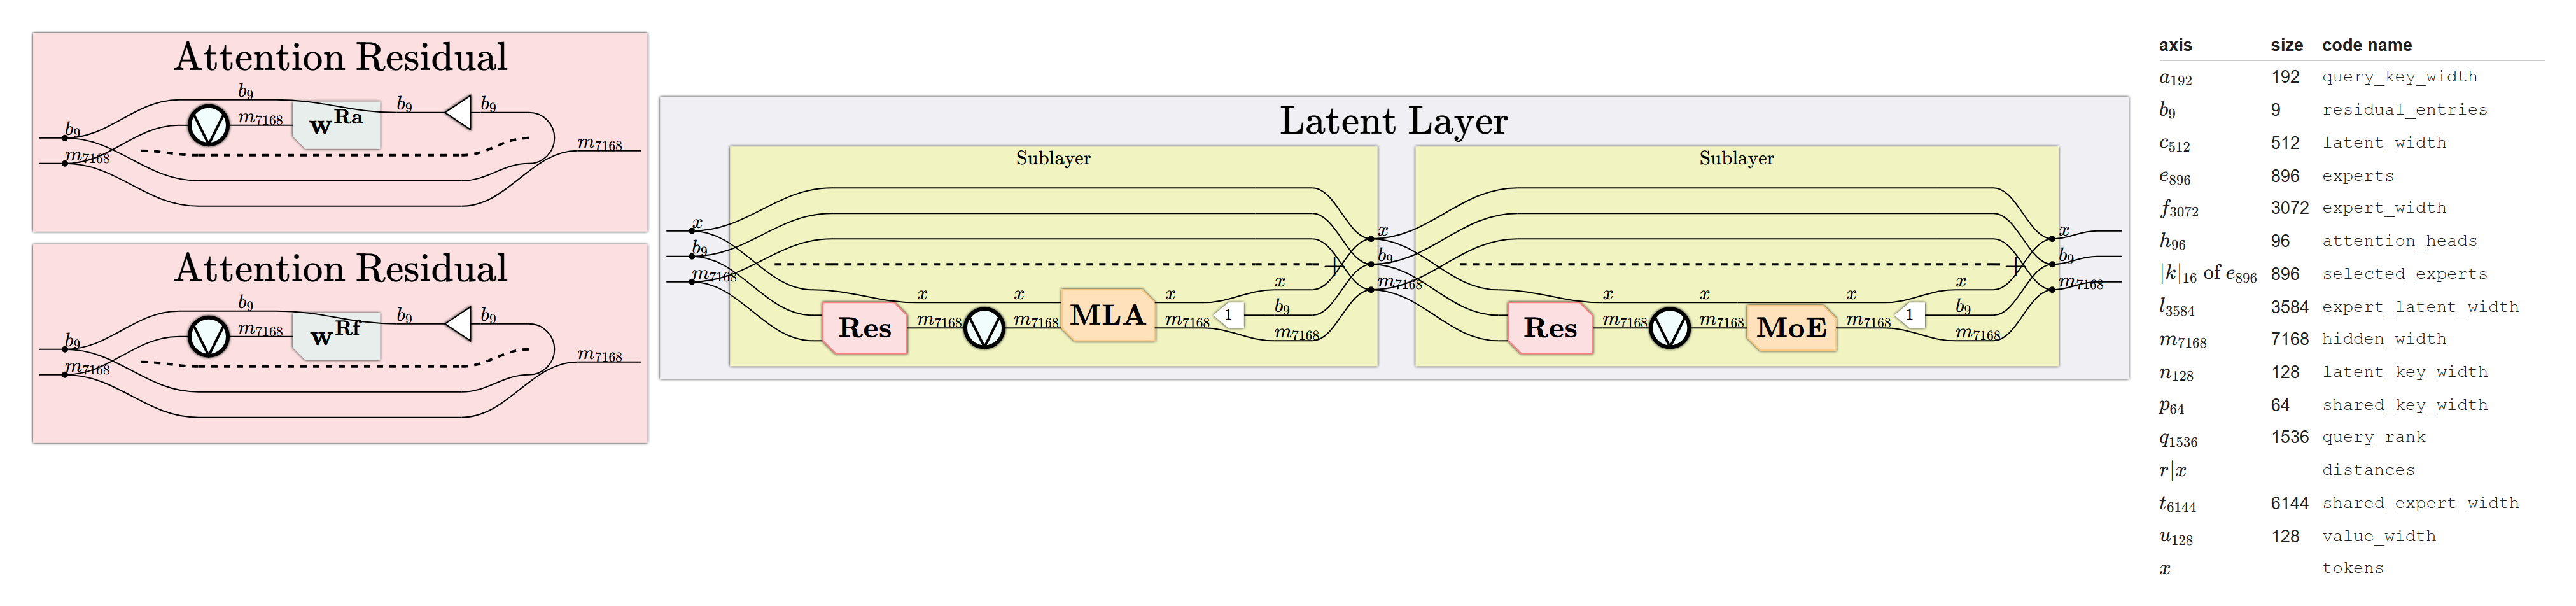

In [9]:
await figures.show(
    whole_model.part_titled(text.LATENT_LAYER_TITLE, DECODE),
    'Layer 3, a latent layer, with the attention residuals around its two sublayers. Each '
    'sublayer reads its own mix of the entries, drawn once as the box Res beside its body, '
    'normalises it, runs the latent attention or the mixture of experts, and adds its '
    'output at entry 1.',
    width=1800, assigned_sizes=assigned_sizes, settings=DIAGRAMS)

## The 93 layers

`config.is_kda_layer` gives layer $i$ the delta attention when $i + 1$ is listed in `kda_layers`, and the latent attention otherwise ([configuration_kimi_k3.py L152-L156](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/configuration_kimi_k3.py#L152-L156), [config.json L66-L165](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/config.json#L66-L165)). The list counts from one, and it lists 69 layers, so layers 0 to 2 are delta layers, every fourth layer from layer 3 is a latent layer, and layers 91 and 92 are both latent layers. The plan is written as three blocks of the attention residuals. The first block holds layer 0, two delta layers, a latent layer and two groups of three delta layers and a latent layer. Six blocks are one block repeated six times with the counter $o$, each three groups of four layers adding their outputs at entry $o + 2$. The last block holds two groups of four and layer 92, and adds its outputs at entry 8. The counts add to $12 + 6 \times 12 + 9 = 93$ layers.

The embedding looks the token identifiers up in a table of 163,840 rows of 7,168 channels and writes the result at entry 0 ([L1096-L1097](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L1096-L1097), [L1156-L1158](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L1156-L1158)). After the last layer, a last mix reads the embedding and the sums of the eight blocks, the RMS normalisation of the final hidden state follows, and the output head maps it onto a logit for every entry of the vocabulary ([L1215-L1219](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L1215-L1219), [L1226-L1233](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L1226-L1233), [L1298-L1301](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L1298-L1301)). The output head has weights of its own, because `tie_word_embeddings` is false ([config.json L254](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/config.json#L254)).

The whole model, drawn with the body of every box left out: the embedding written at entry 0, the first block of twelve layers, the six repeated blocks with the counter o, the last block of nine layers, and the output logits.


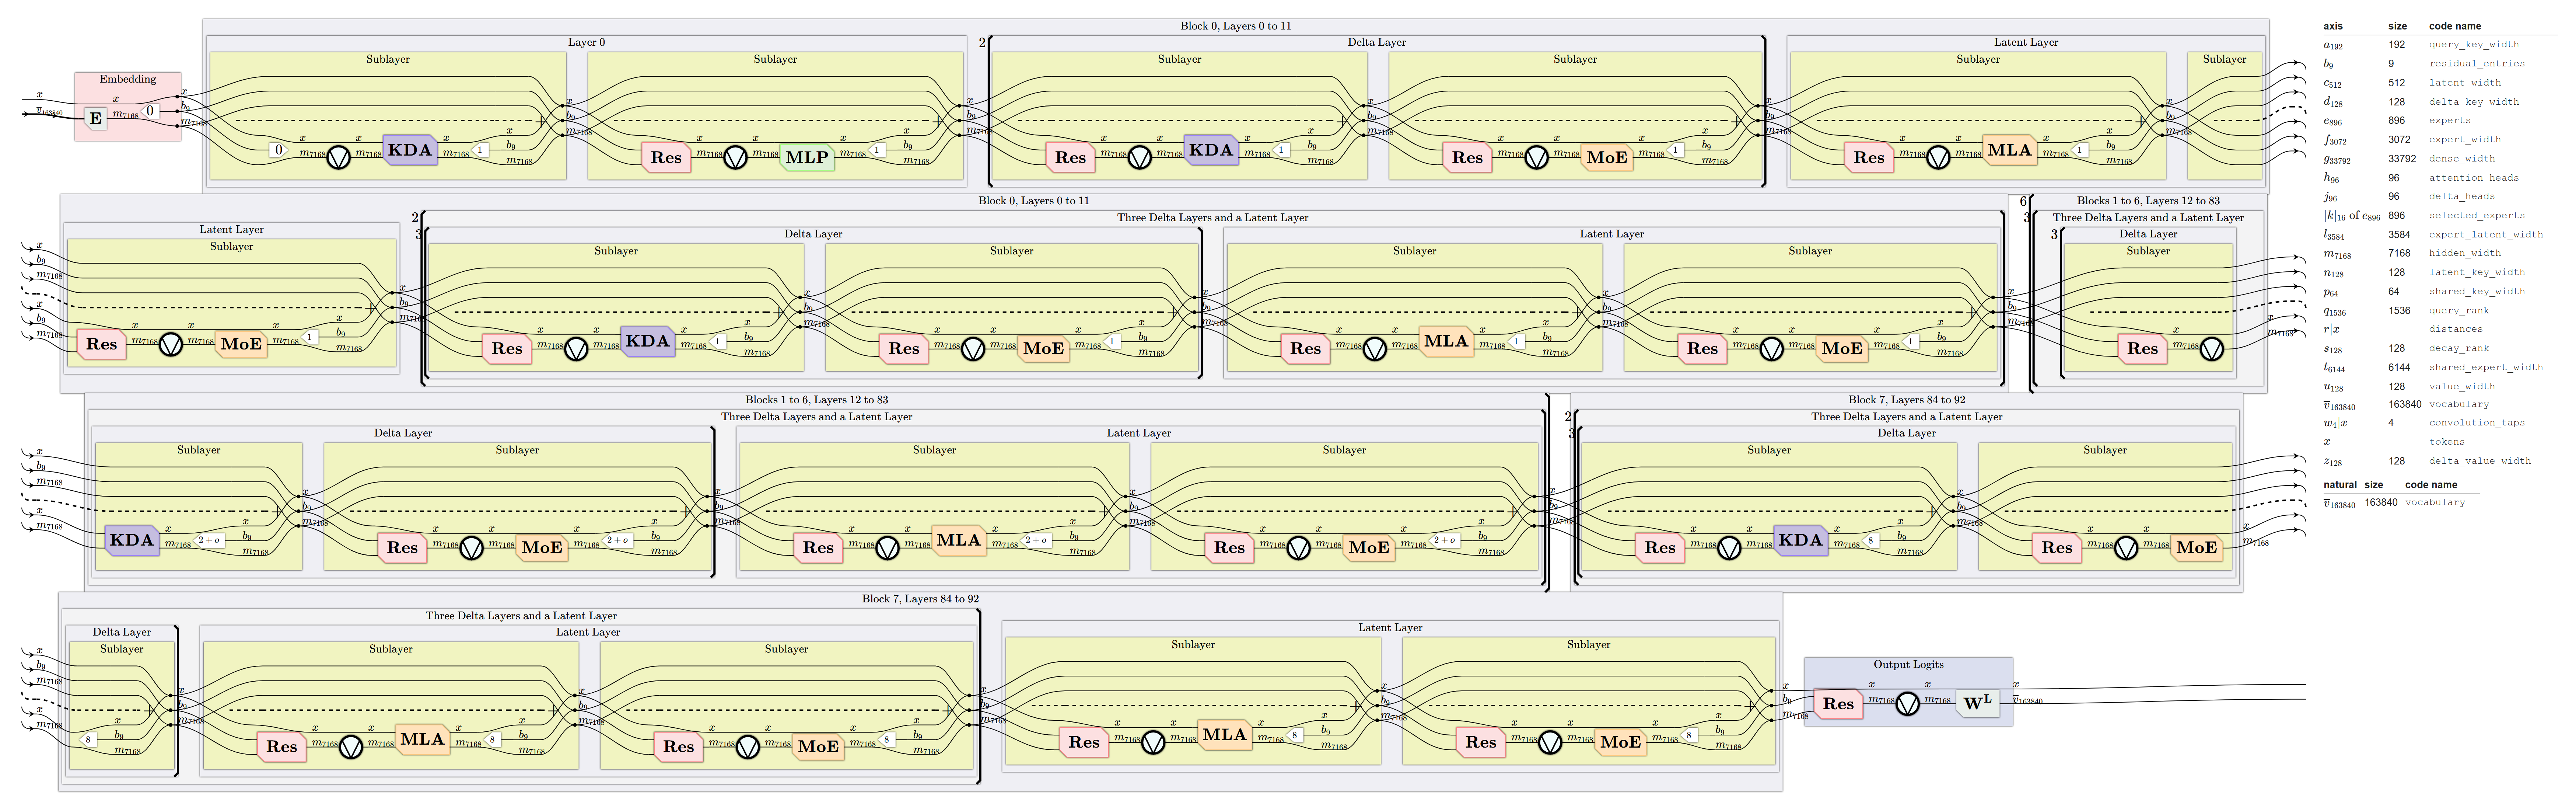

In [10]:
await figures.show(
    DECODE,
    'The whole model, drawn with the body of every box left out: the embedding written at '
    'entry 0, the first block of twelve layers, the six repeated blocks with the counter o, '
    'the last block of nine layers, and the output logits.',
    width=3000, sub_blocks=figures.SubBlocks.NO_BODIES,
    assigned_sizes=assigned_sizes, settings=DIAGRAMS)

## Reading back from each token and the CausalSlide

The model reads earlier tokens in two places. The latent attention reads the keys and the values of every head at token $i_{x} - i_{r}$ at distance $i_{r}$ of each query $i_{x}$, through the view named Back. The three convolutions of a delta layer read token $i_{x} - i_{w}$ at tap $i_{w}$, through the view named Taps. An operation broadcast over the tokens computes the same function at every token, so reading its result at an earlier token gives the values that reading its operand at the earlier token and computing the operation there gives.

The figures above place every read back as early as it can stand, which is at the copy of the hidden state whose other branches read the hidden state at the token itself. That arrangement of the expression is called the CausalSlide. In a latent layer the reads of the keys and of the values meet at the copy of the latent and pass it, and stop at the copy of the hidden state that also feeds the queries and the output gate. In a delta layer the three reads of the taps meet at the copy of the hidden state that also feeds the decays, the strengths and the output gate, and the projections of the queries, the keys and the values then run over the tokens and the taps. The CausalSlide changes no value computed by the expression, and the validator evaluates the delta attention on numbers in both arrangements.

The loop of the scan reads its tokens at the counter, which is no read back. The slide receives no read from the results of the loop and passes it whole.

## The model on one page

The last cell writes the model into `notebooks/website/output/modern/KimiK3/index.html`, one file that opens with no server and no network. The page draws the model reading every token of the prompt, in the CausalSlide and in the reals, with the legend of its axes and an inspection box over every block, operator, weight and view.

The GLM-5.3 and DeepSeek-V4.1-Flash pages carry a quantised form beside the model in the reals, and the GLM-5.3 page a pass over new tokens with its caches as well. This page carries neither. `caching.algebra.derive_cached_pass` has no rule yet for a loop over the tokens, and `obsidian/08-caching/Carrying the State of a Scan Between Passes.md` states the rule it needs. The quantisation of the checkpoint is stated in the next section.

In [11]:
await notebook_diagrams.show_page_variants(
    assemble_page_variants.page_variants(PAGE),
    'Kimi K3 as one page: the model reading every token of the prompt, in the reals.',
    settings=PAGE, slug=assemble_page_variants.PAGE_SLUG,
    initial=assemble_page_variants.INITIAL_VARIANT)

Kimi K3 as one page: the model reading every token of the prompt, in the reals.


(written to notebooks/website/output/modern/KimiK3/)


## Facts left unstated by the figures

- The checkpoint stores the three weights of every routed expert in MXFP4, as `weight_packed` with one `weight_scale` per group of 32 weights, and every other tensor of the text model unpacked ([config.json L202-L240](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/config.json#L202-L240), [model.safetensors.index.json](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/model.safetensors.index.json)). The model card states that Moonshot AI trained with MXFP4 weights and MXFP8 activations from the supervised stage onwards. Every wire of the figures holds reals.
- The reference computes the delta rule with `chunk_kda` for a prompt, in blocks of 64 tokens, and with `fused_recurrent_kda` for one new token read against a cache ([L561](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L561)). The expression writes the recurrence one token at a time, as `naive_recurrent_kda` does. The three compute the same function in the reals and round differently in floating point.
- `KimiDynamicCache` keeps the last inputs of every convolution and the state of every head for a delta layer, and the expanded keys and values of every head for a latent layer ([L120-L173](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L120-L173), [L442-L444](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L442-L444)). The expression states one pass over the whole prompt.
- The expression holds no batch axis. The reference removes the padding of a batch of prompts of different lengths before the scan and restores it after ([L565-L570](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L565-L570), [L660-L661](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L660-L661)).
- The vision encoder MoonViT-V2 and the projector that writes image features into the embeddings are left out ([modeling_kimi_k3.py L899-L917](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_k3.py#L899-L917)).
- `num_nextn_predict_layers` is 0 ([config.json L189](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/config.json#L189)), so the checkpoint holds no layer for multi-token prediction.

## The reference implementation

The reference is `modeling_kimi_linear.py`, `configuration_kimi_k3.py` and `modeling_kimi_k3.py` of `moonshotai/Kimi-K3`, and the `config.json` of the same repository, read at the commit `f831ab668142` on 2026-09-28. The kernels are those of `fla-org/flash-linear-attention` at the tag `v0.5.2`, the commit `9c8e42e762fc`. The same links stand in the inspection box over every block on the page. This notebook follows the released code.

| mechanism | here | reference | lines |
| --- | --- | --- | --- |
| Embedding and output head | `whole_model.embed`, `whole_model.output_logits` | `embed_tokens`, `_apply_output_attn_res`, `norm`, `lm_head` | [L1096-L1097](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L1096-L1097), [L1215-L1233](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L1215-L1233), [L1247-L1248](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L1247-L1248) |
| Attention residuals | `attention_residuals` | `_forward_attn_residual`, `_apply_attn_res` | [L973-L1046](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L973-L1046), [L1075-L1088](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L1075-L1088) |
| Sublayer | `layer_stack.residual_sublayer` | `KimiDecoderLayer` | [L877-L1046](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L877-L1046) |
| RMS normalisation | `ops.Normalize` | `KimiRMSNorm` | [L226-L236](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L226-L236) |
| Causal convolution | `delta_attention.causal_convolution` | `ShortConvolution` | [L504-L518](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L504-L518), [fla short_conv.py L24-L69](https://github.com/fla-org/flash-linear-attention/blob/9c8e42e762fce087c27b673af4922795d9edb85e/fla/modules/conv/short_conv.py#L24-L69) |
| Queries, keys and values of the delta attention | `delta_attention.queries_keys_and_values` | `q_proj`, `k_proj`, `v_proj`, `l2norm_fwd` | [L580-L607](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L580-L607), [fla chunk.py L54-L58](https://github.com/fla-org/flash-linear-attention/blob/9c8e42e762fce087c27b673af4922795d9edb85e/fla/ops/kda/chunk.py#L54-L58) |
| Decays and strengths | `delta_attention.decays`, `delta_attention.strengths` | `f_a_proj`, `f_b_proj`, `b_proj`, `naive_kda_lowerbound_gate` | [L601-L603](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L601-L603), [fla gate.py L58-L70](https://github.com/fla-org/flash-linear-attention/blob/9c8e42e762fce087c27b673af4922795d9edb85e/fla/ops/kda/gate.py#L58-L70) |
| Delta rule scan | `delta_rule_scan` | `chunk_kda`, `naive_recurrent_kda` | [L609-L645](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L609-L645), [fla naive.py L12-L66](https://github.com/fla-org/flash-linear-attention/blob/9c8e42e762fce087c27b673af4922795d9edb85e/fla/ops/kda/naive.py#L12-L66) |
| Gated output of the delta attention | `delta_attention.normalise_and_gate_the_output` | `g_proj`, `o_norm`, `o_proj` | [L651-L659](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L651-L659), [fla fused_norm_gate.py L1001-L1061](https://github.com/fla-org/flash-linear-attention/blob/9c8e42e762fce087c27b673af4922795d9edb85e/fla/modules/fused_norm_gate.py#L1001-L1061) |
| Gated latent attention | `latent_attention` | `KimiMLAAttention` | [L335-L474](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L335-L474) |
| Dense MLP and shared experts | `feed_forward.situ_glu` | `KimiMLP`, `SituAndMul` | [L64-L91](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L64-L91), [L273-L301](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L273-L301) |
| Router | `latent_mixture_of_experts.expert_gate` | `KimiMoEGate` | [L666-L759](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L666-L759) |
| Routed experts and the latent | `latent_mixture_of_experts.through_the_latent` | `KimiBlockSparseMLP`, `routed_expert_down_proj`, `routed_expert_norm`, `routed_expert_up_proj` | [L242-L270](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L242-L270), [L803-L832](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/modeling_kimi_linear.py#L803-L832) |
| Layer plan | `layer_stack` | `is_kda_layer`, `kda_layers`, `full_attn_layers` | [configuration_kimi_k3.py L152-L156](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/configuration_kimi_k3.py#L152-L156), [config.json L66-L165](https://huggingface.co/moonshotai/Kimi-K3/blob/f831ab66814297da540d832a5235f8e904f29d06/config.json#L66-L165) |